<a href="https://colab.research.google.com/github/allifilhamm/Fashion/blob/main/Fashioncolab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [ ]:
import os

os.listdir()

['.config', 'Womens Clothing E-Commerce Reviews.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv(
    'Womens Clothing E-Commerce Reviews.csv'
)

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
df.shape

(23486, 11)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [ ]:
df = df.dropna(
    subset=[
        'Clothing ID',
        'Rating',
        'Class Name'
    ]
)

In [ ]:
import numpy as np

np.random.seed(42)

df['User_ID'] = np.random.randint(
    1,
    1001,
    size=len(df)
)

In [ ]:
recommendation_df = df[
    [
        'User_ID',
        'Clothing ID',
        'Rating',
        'Class Name'
    ]
]

In [ ]:
recommendation_df.head()

,User_ID,Clothing ID,Rating,Class Name
0,103,767,4,Intimates
1,436,1080,5,Dresses
2,861,1077,3,Dresses
3,271,1049,5,Pants
4,107,847,5,Blouses


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=recommendation_df)

https://docs.google.com/spreadsheets/d/1LtXIj_7_fNtHr0zpIDhumocRtXxDci-D0yRuDQov-Ck/edit#gid=0


In [ ]:
recommendation_df.to_csv(
    'fashion_recommendation.csv',
    index=False
)

In [ ]:
recommendation_df['Rating'].value_counts()

,count
Rating,
5,13117
4,5077
3,2871
2,1565
1,842


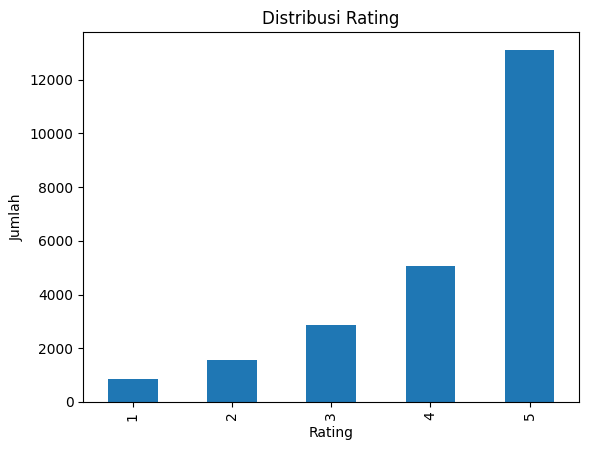

In [ ]:
import matplotlib.pyplot as plt

recommendation_df['Rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
df.shape
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3809
Review Text,844
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0


In [ ]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.9 MB/s eta 0:00:00


In [ ]:
recommendation_df = df[
    [
        'User_ID',
        'Clothing ID',
        'Rating'
    ]
]

recommendation_df.head()

,User_ID,Clothing ID,Rating
0,103,767,4
1,436,1080,5
2,861,1077,3
3,271,1049,5
4,107,847,5


In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic

In [ ]:
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    recommendation_df[
        ['User_ID','Clothing ID','Rating']
    ],
    reader
)

In [ ]:
trainset = data.build_full_trainset()

In [ ]:
cf_model = KNNBasic()

cf_model.fit(trainset)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [ ]:
prediction = cf_model.predict(
    uid=1,
    iid=767
)

print(prediction.est)

4.78125


In [ ]:
from surprise import SVD

svd_model = SVD()

svd_model.fit(trainset)

In [ ]:
svd_model = SVD()

svd_model.fit(trainset)

In [ ]:
prediction = svd_model.predict(
    uid=1,
    iid=767
)

print(prediction.est)

4.350210852692835


In [ ]:
from surprise.model_selection import train_test_split

trainset,testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [ ]:
svd_model = SVD()

svd_model.fit(trainset)

In [ ]:
predictions = svd_model.test(testset)

In [ ]:
from surprise import accuracy

accuracy.rmse(predictions)

RMSE: 1.1230


np.float64(1.1230413755479718)

In [ ]:
pivot_table = recommendation_df.pivot_table(
    index='Clothing ID',
    columns='User_ID',
    values='Rating'
).fillna(0)

pivot_table.head()

User_ID,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
Clothing ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(pivot_table)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
distances, indices = knn_model.kneighbors(
    pivot_table.iloc[0,:].values.reshape(1,-1),
    n_neighbors=6
)

In [ ]:
indices

array([[   0,   91, 1044, 1084,  869,  828]])

In [ ]:
import pickle

pickle.dump(
    cf_model,
    open('cf_model.pkl','wb')
)

pickle.dump(
    svd_model,
    open('svd_model.pkl','wb')
)

pickle.dump(
    knn_model,
    open('knn_model.pkl','wb')
)

In [ ]:
import pandas as pd

def get_top_n_recommendations(user_id, model, df, n=10):

    # Ambil semua produk unik
    all_products = df['Clothing ID'].unique()

    # Produk yang sudah pernah diberi rating user
    rated_products = df[
        df['User_ID'] == user_id
    ]['Clothing ID'].unique()

    # Produk yang belum pernah dirating
    unseen_products = [
        product
        for product in all_products
        if product not in rated_products
    ]

    predictions = []

    # Prediksi rating untuk produk yang belum pernah dilihat
    for product in unseen_products:

        pred = model.predict(
            uid=user_id,
            iid=product
        )

        predictions.append(
            (
                product,
                pred.est
            )
        )

    # Urutkan berdasarkan skor prediksi tertinggi
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Ambil Top-N
    top_n = predictions[:n]

    return pd.DataFrame(
        top_n,
        columns=[
            'Clothing_ID',
            'Predicted_Rating'
        ]
    )

In [ ]:
top10 = get_top_n_recommendations(
    user_id=1,
    model=svd_model,
    df=recommendation_df,
    n=10
)

top10

,Clothing_ID,Predicted_Rating
0,715,4.598991
1,375,4.591602
2,967,4.581368
3,662,4.576294
4,961,4.560887
5,1026,4.554646
6,382,4.537609
7,667,4.513821
8,231,4.496855
9,1080,4.487442


In [ ]:
def get_top_n_with_product_info(
    user_id,
    model,
    df,
    n=10
):

    recommendations = get_top_n_recommendations(
        user_id,
        model,
        df,
        n
    )

    product_info = df[
        [
            'Clothing ID',
            'Class Name',
            'Department Name'
        ]
    ].drop_duplicates()

    result = recommendations.merge(
        product_info,
        left_on='Clothing_ID',
        right_on='Clothing ID',
        how='left'
    )

    return result[
        [
            'Clothing_ID',
            'Class Name',
            'Department Name',
            'Predicted_Rating'
        ]
    ]

In [ ]:
recommendation_result = get_top_n_with_product_info(
    user_id=1,
    model=svd_model,
    df=df,
    n=10
)

recommendation_result

,Clothing_ID,Class Name,Department Name,Predicted_Rating
0,715,Lounge,Intimate,4.598991
1,375,Lounge,Intimate,4.591602
2,967,Jackets,Jackets,4.581368
3,662,Lounge,Intimate,4.576294
4,961,Jackets,Jackets,4.560887
5,1026,Jeans,Bottoms,4.554646
6,382,Swim,Intimate,4.537609
7,667,Lounge,Intimate,4.513821
8,231,Sleep,Intimate,4.496855
9,1080,Dresses,Dresses,4.487442


In [ ]:
import pickle

pickle.dump(
    svd_model,
    open('svd_model.pkl','wb')
)

pickle.dump(
    cf_model,
    open('cf_model.pkl','wb')
)

pickle.dump(
    knn_model,
    open('knn_model.pkl','wb')
)

In [ ]:
from google.colab import files

files.download('svd_model.pkl')
files.download('cf_model.pkl')
files.download('knn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv(
    'fashion_dataset_final.csv',
    index=False
)

In [ ]:
files.download(
    'fashion_dataset_final.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def user_history(user_id, df):

    history = df[
        df['User_ID'] == user_id
    ][[
        'Clothing ID',
        'Class Name',
        'Rating'
    ]]

    return history

In [ ]:
user_history(1, df)

,Clothing ID,Class Name,Rating
897,1008,Skirts,4
1049,949,Sweaters,5
1357,895,Fine gauge,4
1585,1059,Pants,5
2760,878,Knits,5
2839,949,Sweaters,5
4234,940,Sweaters,5
4511,1095,Dresses,4
4934,823,Blouses,3
5758,1078,Dresses,4


In [ ]:
total_user = df['User_ID'].nunique()

total_produk = df['Clothing ID'].nunique()

total_interaksi = len(df)

print(total_user)
print(total_produk)
print(total_interaksi)

1000
1199
23472


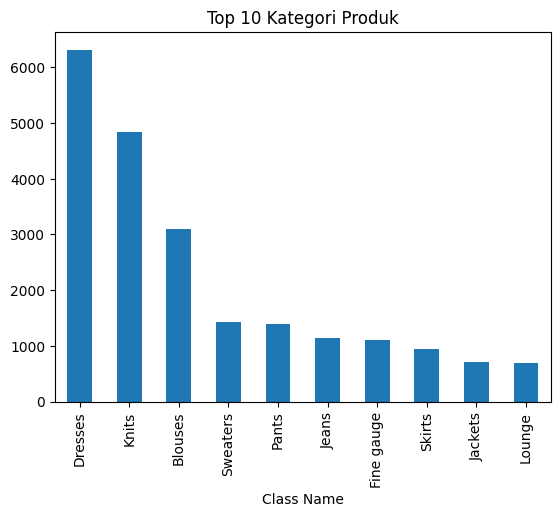

In [ ]:
import matplotlib.pyplot as plt

df['Class Name'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    'Top 10 Kategori Produk'
)

plt.show()

In [ ]:
from surprise import accuracy

predictions = svd_model.test(testset)

rmse_svd = accuracy.rmse(predictions, verbose=False)
mae_svd = accuracy.mae(predictions, verbose=False)

print("RMSE:", rmse_svd)
print("MAE:", mae_svd)

RMSE: 1.1230413755479718
MAE: 0.8925646471362226


In [ ]:
predictions_cf = cf_model.test(testset)

rmse_cf = accuracy.rmse(
    predictions_cf,
    verbose=False
)

mae_cf = accuracy.mae(
    predictions_cf,
    verbose=False
)

print("RMSE CF:", rmse_cf)
print("MAE CF:", mae_cf)

RMSE CF: 0.6796006424550084
MAE CF: 0.4798181762832359


In [ ]:
results = {
    'Model': ['CF', 'SVD'],
    'RMSE': [
        0.6796006424550084,
        1.1230413755479718
    ],
    'MAE': [
        0.4798181762832359,
        0.8925646471362226
    ]
}

result_df = pd.DataFrame(results)

result_df

,Model,RMSE,MAE
0,CF,0.679601,0.479818
1,SVD,1.123041,0.892565


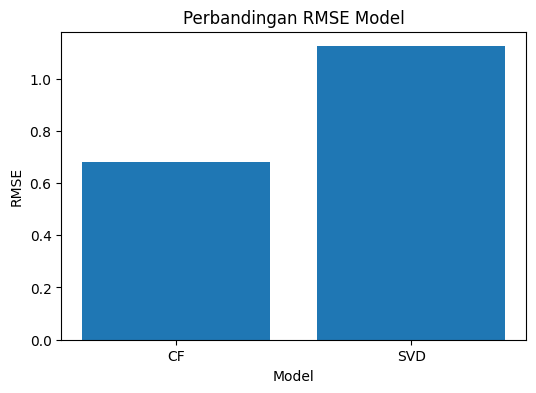

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    result_df['Model'],
    result_df['RMSE']
)

plt.title('Perbandingan RMSE Model')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.show()

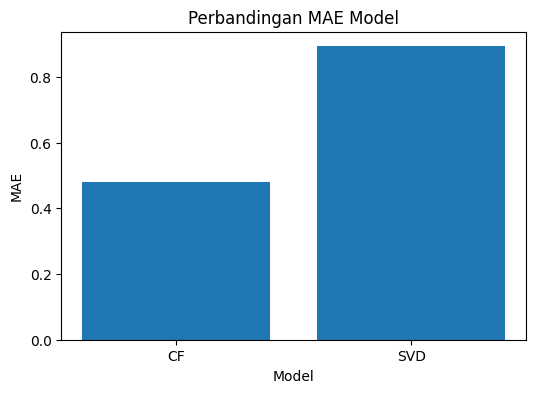

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    result_df['Model'],
    result_df['MAE']
)

plt.title('Perbandingan MAE Model')
plt.xlabel('Model')
plt.ylabel('MAE')

plt.show()

In [ ]:
from collections import defaultdict

def get_top_n(predictions, n=10):

    top_n = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():

        user_ratings.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top_n[uid] = user_ratings[:n]

    return top_n

In [ ]:
def precision_recall_at_k(
    predictions,
    k=10,
    threshold=4
):

    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append(
            (est, true_r)
        )

    precisions = dict()
    recalls = dict()

    for uid, ratings in user_est_true.items():

        ratings.sort(
            key=lambda x: x[0],
            reverse=True
        )

        n_rel = sum(
            (true_r >= threshold)
            for (_, true_r) in ratings
        )

        n_rec_k = sum(
            (est >= threshold)
            for (est, _) in ratings[:k]
        )

        n_rel_and_rec_k = sum(
            (
                true_r >= threshold
            ) and (
                est >= threshold
            )
            for (est, true_r)
            in ratings[:k]
        )

        precisions[uid] = (
            n_rel_and_rec_k / n_rec_k
            if n_rec_k != 0
            else 0
        )

        recalls[uid] = (
            n_rel_and_rec_k / n_rel
            if n_rel != 0
            else 0
        )

    return precisions, recalls

In [ ]:
precisions, recalls = precision_recall_at_k(
    predictions,
    k=10,
    threshold=4
)

precision_svd = sum(
    precisions.values()
) / len(precisions)

recall_svd = sum(
    recalls.values()
) / len(recalls)

print(
    "Precision@10:",
    precision_svd
)

print(
    "Recall@10:",
    recall_svd
)

Precision@10: 0.7584447017577715
Recall@10: 0.74089151026841


In [ ]:
f1_svd = (
    2 *
    precision_svd *
    recall_svd
) / (
    precision_svd +
    recall_svd
)

print(
    "F1 Score:",
    f1_svd
)

F1 Score: 0.7495653556996552


In [ ]:
precisions_cf, recalls_cf = precision_recall_at_k(
    predictions_cf,
    k=10,
    threshold=4
)

precision_cf = sum(
    precisions_cf.values()
) / len(precisions_cf)

recall_cf = sum(
    recalls_cf.values()
) / len(recalls_cf)

f1_cf = (
    2 *
    precision_cf *
    recall_cf
) / (
    precision_cf +
    recall_cf
)

results = {
    'Model': ['CF','SVD'],
    'RMSE': [
        rmse_cf,
        rmse_svd
    ],
    'MAE': [
        mae_cf,
        mae_svd
    ],
    'Precision': [
        precision_cf,
        precision_svd
    ],
    'Recall': [
        recall_cf,
        recall_svd
    ],
    'F1-Score': [
        f1_cf,
        f1_svd
    ]
}

result_df = pd.DataFrame(results)

result_df

,Model,RMSE,MAE,Precision,Recall,F1-Score
0,CF,0.679601,0.479818,0.948013,0.941323,0.944656
1,SVD,1.123041,0.892565,0.758445,0.740892,0.749565


In [ ]:
result_df.to_excel(
    "hasil_evaluasi.xlsx",
    index=False
)

In [ ]:
import os
os.listdir()

['.config',
 'hasil_evaluasi.xlsx',
 'Womens Clothing E-Commerce Reviews.csv',
 'fashion_dataset_final.csv',
 'knn_model.pkl',
 'svd_model.pkl',
 'fashion_recommendation.csv',
 'cf_model.pkl',
 'sample_data']

In [ ]:
result_df

,Model,RMSE,MAE,Precision,Recall,F1-Score
0,CF,0.679601,0.479818,0.948013,0.941323,0.944656
1,SVD,1.123041,0.892565,0.758445,0.740892,0.749565


In [ ]:
from google.colab import files

files.download('hasil_evaluasi.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("RMSE SVD:", rmse_svd)
print("MAE SVD:", mae_svd)

print("Precision SVD:", precision_svd)
print("Recall SVD:", recall_svd)
print("F1 SVD:", f1_svd)

RMSE SVD: 1.1230413755479718
MAE SVD: 0.8925646471362226
Precision SVD: 0.7584447017577715
Recall SVD: 0.74089151026841
F1 SVD: 0.7495653556996552


In [ ]:
pip install streamlit pandas openpyxl matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.4 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Fashion Recommendation System",
    layout="wide"
)

st.title("Fashion Recommendation System")

st.write(
    "Sistem Rekomendasi Produk Fashion Menggunakan Collaborative Filtering, KNN, dan SVD"
)

df = pd.read_csv(
    "fashion_dataset_final.csv"
)

st.subheader("Dataset")

st.dataframe(df.head())

df = pd.read_csv(
    "fashion_dataset_final.csv"
)

st.subheader("Dataset")

st.dataframe(df.head())

st.header("Dashboard Admin")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Total User",
    df["User_ID"].nunique()
)

col2.metric(
    "Total Produk",
    df["Clothing ID"].nunique()
)

col3.metric(
    "Total Interaksi",
    len(df)
)

st.header("Katalog Produk")

produk = df[
    [
        "Clothing ID",
        "Class Name",
        "Department Name"
    ]
].drop_duplicates()

st.dataframe(produk)

st.header("Histori User")

user = st.number_input(
    "Masukkan User ID",
    min_value=1
)

history = df[
    df["User_ID"] == user
]

st.dataframe(
    history[
        [
            "Clothing ID",
            "Class Name",
            "Rating"
        ]
    ]
)

2026-06-15 16:52:27.311 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 16:52:27.313 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 16:52:27.676 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-15 16:52:27.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 16:52:27.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 16:52:27.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 16:52:27.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!ls

 cf_model.pkl		      knn_model.pkl
 fashion_dataset_final.csv    sample_data
 fashion_recommendation.csv   svd_model.pkl
 hasil_evaluasi.xlsx	     'Womens Clothing E-Commerce Reviews.csv'


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3EfYwpLKLfCDdU0Q1RB4WHqdEiw_24aP2vinGRnUM3MnnV9Go")

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://haphazard-compel-handpick.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py > logs.txt 2>&1 &

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://haphazard-compel-handpick.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!tail -30 logs.txt

In [81]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import pickle

print("1. Membaca dataset...")
df = pd.read_csv("fashion_dataset_final.csv")

print("2. Membuat user-item matrix...")
matrix = df.pivot_table(
    index="User_ID",
    columns="Clothing ID",
    values="Rating",
    aggfunc="mean"
).fillna(0)

print(f"Bentuk matriks: {matrix.shape}")

print("3. Melatih ulang model KNN...")
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')

knn_model.fit(matrix)

print("4. Menyimpan model...")
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn_model, f)

print("✅ Selesai! knn_model.pkl berhasil diperbarui.")

1. Membaca dataset...
2. Membuat user-item matrix...
Bentuk matriks: (1000, 1199)
3. Melatih ulang model KNN...
4. Menyimpan model...
✅ Selesai! knn_model.pkl berhasil diperbarui.


In [82]:
import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from io import BytesIO
import numpy as np
from surprise import Reader, Dataset, accuracy
from surprise.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error
)

st.set_page_config(
    page_title="Fashion Recommendation System",
    page_icon="👗",
    layout="wide"
)

@st.cache_data
def load_data():
    return pd.read_csv("fashion_dataset_final.csv")

@st.cache_resource
def load_models():
    cf = pickle.load(open("cf_model.pkl", "rb"))
    svd = pickle.load(open("svd_model.pkl", "rb"))
    knn = pickle.load(open("knn_model.pkl", "rb"))
    return cf, svd, knn

df = load_data()
cf_model, svd_model, knn_model = load_models()


if "login" not in st.session_state:
    st.session_state.login = False

if not st.session_state.login:

    st.title("👗 Fashion Recommendation System")

    st.markdown("### Login Sistem")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):

        if username == "admin" and password == "admin123":
            st.session_state.login = True
            st.rerun()
        else:
            st.error("Username atau password salah")

    st.stop()

st.sidebar.title("Fashion Recommendation")

menu = st.sidebar.radio(
    "Pilih Menu",
    [
        "Dashboard",
        "Katalog Produk",
        "Histori User",
        "Rekomendasi Produk",
        "Visualisasi Akurasi"
    ]
)


def get_top_n_recommendations(
    user_id,
    model,
    df,
    n=10
):

    all_products = df["Clothing ID"].unique()

    rated_products = df[
        df["User_ID"] == user_id
    ]["Clothing ID"].unique()

    unseen_products = [
        product
        for product in all_products
        if product not in rated_products
    ]

    predictions = []

    for product in unseen_products:

        pred = model.predict(
            uid=user_id,
            iid=product
        )

        predictions.append(
            (
                product,
                pred.est
            )
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_n = predictions[:n]

    recommendation_df = pd.DataFrame(
        top_n,
        columns=[
            "Clothing_ID",
            "Predicted_Rating"
        ]
    )

    product_info = df[
        [
            "Clothing ID",
            "Class Name",
            "Department Name"
        ]
    ].drop_duplicates()

    result = recommendation_df.merge(
        product_info,
        left_on="Clothing_ID",
        right_on="Clothing ID",
        how="left"
    )

    return result[
        [
            "Clothing_ID",
            "Class Name",
            "Department Name",
            "Predicted_Rating"
        ]
    ]

@st.cache_data
def build_user_item_matrix(_df):
    """
    Buat user-item matrix dari dataframe.
    Baris = user, kolom = produk.
    """
    matrix = _df.pivot_table(
        index="User_ID",
        columns="Clothing ID",
        values="Rating",
        aggfunc="mean"
    ).fillna(0)
    return matrix

def get_top_n_recommendations_knn(
    user_id,
    model,
    df,
    n=10
):
    matrix = build_user_item_matrix(df)

    if hasattr(model, 'feature_names_in_'):
        matrix = matrix.reindex(columns=model.feature_names_in_, fill_value=0)

    if user_id not in matrix.index:
        return pd.DataFrame(
            columns=[
                "Clothing_ID",
                "Class Name",
                "Department Name",
                "Predicted_Rating"
            ]
        )

    user_idx = matrix.index.get_loc(user_id)
    user_vector = matrix.iloc[user_idx].values.reshape(1, -1)

    k = min(20, model.n_samples_fit_)
    distances, indices = model.kneighbors(user_vector, n_neighbors=k)

    neighbor_indices = indices[0]
    neighbor_distances = distances[0]

    rated_products = set(
        df[df["User_ID"] == user_id]["Clothing ID"].unique()
    )

    product_scores = {}

    for neighbor_idx, distance in zip(neighbor_indices, neighbor_distances):

        neighbor_user_id = matrix.index[neighbor_idx]
        similarity = 1 / (1 + distance)

        neighbor_ratings = df[
            df["User_ID"] == neighbor_user_id
        ][["Clothing ID", "Rating"]]

        for _, row in neighbor_ratings.iterrows():

            product = row["Clothing ID"]
            rating = row["Rating"]

            if product in rated_products:
                continue

            if product not in product_scores:
                product_scores[product] = {"score": 0, "weight": 0}

            product_scores[product]["score"]  += similarity * rating
            product_scores[product]["weight"] += similarity

    predictions = []

    for product, val in product_scores.items():
        if val["weight"] > 0:
            predicted_rating = val["score"] / val["weight"]
            predictions.append((product, round(predicted_rating, 4)))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]

    if not top_n:
        return pd.DataFrame(
            columns=[
                "Clothing_ID",
                "Class Name",
                "Department Name",
                "Predicted_Rating"
            ]
        )

    recommendation_df = pd.DataFrame(
        top_n,
        columns=["Clothing_ID", "Predicted_Rating"]
    )

    product_info = df[
        ["Clothing ID", "Class Name", "Department Name"]
    ].drop_duplicates()

    result = recommendation_df.merge(
        product_info,
        left_on="Clothing_ID",
        right_on="Clothing ID",
        how="left"
    )

    return result[
        ["Clothing_ID", "Class Name", "Department Name", "Predicted_Rating"]
    ]

# ==================== LOGIKA EVALUASI (DIBUNGKUS CACHE) ====================
def evaluate_surprise_model(model, testset, threshold=3.5):
    predictions = model.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions,  verbose=False)

    y_true = [1 if pred.r_ui >= threshold else 0 for pred in predictions]
    y_pred = [1 if pred.est  >= threshold else 0 for pred in predictions]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return {
        "RMSE":      round(rmse,      4),
        "MAE":       round(mae,       4),
        "Precision": round(precision, 4),
        "Recall":    round(recall,    4),
        "F1-Score":  round(f1,        4),
    }

def evaluate_knn_model(knn_model, df, threshold=3.5, test_size=0.2, random_state=42):
    matrix = df.pivot_table(index="User_ID", columns="Clothing ID", values="Rating", aggfunc="mean").fillna(0)
    if hasattr(knn_model, 'feature_names_in_'):
        matrix = matrix.reindex(columns=knn_model.feature_names_in_, fill_value=0)

    all_users = matrix.index.tolist()
    np.random.seed(random_state)
    test_users = np.random.choice(all_users, size=int(len(all_users) * test_size), replace=False)

    y_true_all = []
    y_pred_all = []

    for user_id in test_users:
        user_idx = matrix.index.get_loc(user_id)
        user_vector = matrix.iloc[user_idx].values.reshape(1, -1)

        k = min(20, knn_model.n_samples_fit_)
        distances, indices = knn_model.kneighbors(user_vector, n_neighbors=k)

        neighbor_indices = indices[0]
        neighbor_distances = distances[0]
        user_ratings = df[df["User_ID"] == user_id][["Clothing ID", "Rating"]]

        if user_ratings.empty:
            continue
        product_scores = {}

        for neighbor_idx, distance in zip(neighbor_indices, neighbor_distances):
            neighbor_user_id = matrix.index[neighbor_idx]
            if neighbor_user_id == user_id:
                continue

            similarity = 1 / (1 + distance)
            neighbor_ratings = df[df["User_ID"] == neighbor_user_id][["Clothing ID", "Rating"]]

            for _, row in neighbor_ratings.iterrows():
                product = row["Clothing ID"]
                rating  = row["Rating"]

                if product not in product_scores:
                    product_scores[product] = {"score": 0, "weight": 0}

                product_scores[product]["score"]  += similarity * rating
                product_scores[product]["weight"] += similarity

        for _, row in user_ratings.iterrows():
            product = row["Clothing ID"]
            actual  = row["Rating"]

            if product in product_scores and product_scores[product]["weight"] > 0:
                predicted = product_scores[product]["score"] / product_scores[product]["weight"]
                y_true_all.append(actual)
                y_pred_all.append(predicted)

    if not y_true_all:
        return {"RMSE": None, "MAE": None, "Precision": None, "Recall": None, "F1-Score": None}

    y_true_arr = np.array(y_true_all)
    y_pred_arr = np.array(y_pred_all)

    rmse = round(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)), 4)
    mae  = round(mean_absolute_error(y_true_arr, y_pred_arr), 4)

    y_true_bin = [1 if v >= threshold else 0 for v in y_true_arr]
    y_pred_bin = [1 if v >= threshold else 0 for v in y_pred_arr]

    precision = round(precision_score(y_true_bin, y_pred_bin, zero_division=0), 4)
    recall    = round(recall_score(y_true_bin, y_pred_bin, zero_division=0), 4)
    f1        = round(f1_score(y_true_bin, y_pred_bin, zero_division=0), 4)

    return {"RMSE": rmse, "MAE": mae, "Precision": precision, "Recall": recall, "F1-Score": f1}

@st.cache_data
def run_all_evaluations(_cf_model, _svd_model, _knn_model, _df):
    # Setup Surprise Dataset split
    reader = Reader(rating_scale=(_df["Rating"].min(), _df["Rating"].max()))
    data = Dataset.load_from_df(_df[["User_ID", "Clothing ID", "Rating"]], reader)
    _, testset = train_test_split(data, test_size=0.2, random_state=42)

    cf_metrics  = evaluate_surprise_model(_cf_model, testset)
    svd_metrics = evaluate_surprise_model(_svd_model, testset)
    knn_metrics = evaluate_knn_model(_knn_model, _df)

    result_df = pd.DataFrame([
        {"Model": "CF",  **cf_metrics},
        {"Model": "SVD", **svd_metrics},
        {"Model": "KNN", **knn_metrics},
    ])
    return result_df
# ===========================================================================


if menu == "Dashboard":

    st.title("📊 Dashboard Admin")

    col1, col2, col3 = st.columns(3)

    col1.metric("Total User", df["User_ID"].nunique())
    col2.metric("Total Produk", df["Clothing ID"].nunique())
    col3.metric("Total Interaksi", len(df))

    st.divider()

    left, right = st.columns(2)

    with left:
        st.subheader("Distribusi Rating")
        fig, ax = plt.subplots()
        df["Rating"].value_counts().sort_index().plot(kind="bar", ax=ax)
        plt.xlabel("Rating")
        plt.ylabel("Jumlah")
        st.pyplot(fig)

    with right:
        st.subheader("Top Kategori Produk")
        fig2, ax2 = plt.subplots()
        df["Class Name"].value_counts().head(10).plot(kind="bar", ax=ax2)
        st.pyplot(fig2)

elif menu == "Katalog Produk":

    st.title("🛍️ Katalog Produk")

    produk = df[["Clothing ID", "Class Name", "Department Name"]].drop_duplicates()
    search = st.text_input("Cari Produk")

    if search:
        produk = produk[produk["Class Name"].astype(str).str.contains(search, case=False, na=False)]

    st.dataframe(produk, use_container_width=True)


elif menu == "Histori User":

    st.title("👤 Histori User")

    user_id = st.number_input("Masukkan User ID", min_value=1, value=1, step=1)
    user_id = int(user_id)

    history = df[df["User_ID"] == user_id]
    st.write(f"Jumlah Interaksi: {len(history)}")

    st.dataframe(history[["Clothing ID", "Class Name", "Rating"]], use_container_width=True)

elif menu == "Rekomendasi Produk":

    st.title("🎯 Sistem Rekomendasi Produk")

    user_id = st.number_input("Masukkan User ID", min_value=1, value=1, step=1)
    user_id = int(user_id)

    model_choice = st.selectbox("Pilih Model", ["SVD", "Collaborative Filtering", "KNN"])

    if model_choice == "SVD":
        selected_model = svd_model
        use_knn = False
    elif model_choice == "KNN":
        selected_model = knn_model
        use_knn = True
    else:
        selected_model = cf_model
        use_knn = False

    if st.button("Generate Recommendation"):

        with st.spinner("Membuat rekomendasi..."):
            if use_knn:
                result = get_top_n_recommendations_knn(user_id=user_id, model=selected_model, df=df, n=10)
            else:
                result = get_top_n_recommendations(user_id=user_id, model=selected_model, df=df, n=10)

        if result.empty:
            st.warning("Tidak ada rekomendasi yang bisa dibuat untuk user ini dengan model KNN. Pastikan user memiliki cukup histori interaksi.")
        else:
            st.success(f"Rekomendasi berhasil dibuat menggunakan model {model_choice}")
            st.dataframe(result, use_container_width=True)

            csv = result.to_csv(index=False).encode()
            st.download_button(
                label="📥 Download CSV",
                data=csv,
                file_name=f"recommendation_{model_choice.lower().replace(' ', '_')}.csv",
                mime="text/csv"
            )

elif menu == "Visualisasi Akurasi":

    st.title("📉 Visualisasi & Perbandingan Akurasi Model")
    st.markdown("Halaman ini membandingkan metrik evaluasi dari model CF, SVD, dan KNN secara langsung.")

    with st.spinner("Menghitung metrik evaluasi model (proses ini menggunakan cache)..."):
        # Menjalankan fungsi evaluasi terbungkus cache
        res_df = run_all_evaluations(cf_model, svd_model, knn_model, df)

    st.success("Evaluasi Berhasil Dimuat!")

    # Menampilkan tabel hasil ke interface Streamlit
    st.dataframe(res_df, use_container_width=True)

    # Menyediakan tombol download Excel langsung dari web UI
    excel_buffer = BytesIO()
    res_df.to_excel(excel_buffer, index=False)
    st.download_button(
        label="📥 Download Hasil Evaluasi (Excel)",
        data=excel_buffer.getvalue(),
        file_name="hasil_evaluasi.xlsx",
        mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
    )

st.sidebar.divider()

st.sidebar.info(
    """
    Fashion Recommendation System

    Collaborative Filtering
    KNN
    SVD

    CRISP-DM Methodology
    """
)

2026-06-15 17:34:12.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.180 No runtime found, using MemoryCacheStorageManager
2026-06-15 17:34:12.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.311 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.321 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:34:12.324 Thread 'MainThread':

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

In [ ]:
!ls

 cf_model.pkl		      logs.txt
 fashion_dataset_final.csv    sample_data
 fashion_recommendation.csv   svd_model.pkl
 hasil_evaluasi.xlsx	     'Womens Clothing E-Commerce Reviews.csv'
 knn_model.pkl


In [ ]:
!nl -ba app.py | sed -n '115,130p'

nl: app.py: No such file or directory


In [ ]:
!grep "streamlit run" app.py

In [ ]:
!pkill -f streamlit

In [ ]:
!rm -f logs.txt

In [ ]:
!streamlit run app.py > logs.txt 2>&1 &

In [ ]:
!cat -n app.py | tail -20

In [ ]:
!pkill -9 -f streamlit

In [ ]:
!ps aux | grep streamlit

In [ ]:
!streamlit run app.py > logs.txt 2>&1 &

In [ ]:
!tail -50 logs.txt

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
!cat -n app.py | tail -30

In [ ]:
import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from io import BytesIO

# ==================================
# PAGE CONFIG
# ==================================

st.set_page_config(
    page_title="Fashion Recommendation System",
    page_icon="👗",
    layout="wide"
)

# ==================================
# LOAD DATA
# ==================================

@st.cache_data
def load_data():
    return pd.read_csv("fashion_dataset_final.csv")

@st.cache_resource
def load_models():
    cf = pickle.load(open("cf_model.pkl", "rb"))
    svd = pickle.load(open("svd_model.pkl", "rb"))
    return cf, svd

df = load_data()
cf_model, svd_model = load_models()

# ==================================
# LOGIN
# ==================================

if "login" not in st.session_state:
    st.session_state.login = False

if not st.session_state.login:

    st.title("👗 Fashion Recommendation System")

    st.markdown("### Login Sistem")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):

        if username == "admin" and password == "admin123":
            st.session_state.login = True
            st.rerun()
        else:
            st.error("Username atau password salah")

    st.stop()

# ==================================
# SIDEBAR
# ==================================

st.sidebar.title("Fashion Recommendation")

menu = st.sidebar.radio(
    "Pilih Menu",
    [
        "Dashboard",
        "Katalog Produk",
        "Histori User",
        "Rekomendasi Produk",
        "Visualisasi Akurasi"
    ]
)

# ==================================
# RECOMMENDATION FUNCTION
# ==================================

def get_top_n_recommendations(
    user_id,
    model,
    df,
    n=10
):

    all_products = df["Clothing ID"].unique()

    rated_products = df[
        df["User_ID"] == user_id
    ]["Clothing ID"].unique()

    unseen_products = [
        product
        for product in all_products
        if product not in rated_products
    ]

    predictions = []

    for product in unseen_products:

        pred = model.predict(
            uid=user_id,
            iid=product
        )

        predictions.append(
            (
                product,
                pred.est
            )
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_n = predictions[:n]

    recommendation_df = pd.DataFrame(
        top_n,
        columns=[
            "Clothing_ID",
            "Predicted_Rating"
        ]
    )

    product_info = df[
        [
            "Clothing ID",
            "Class Name",
            "Department Name"
        ]
    ].drop_duplicates()

    result = recommendation_df.merge(
        product_info,
        left_on="Clothing_ID",
        right_on="Clothing ID",
        how="left"
    )

    return result[
        [
            "Clothing_ID",
            "Class Name",
            "Department Name",
            "Predicted_Rating"
        ]
    ]

# ==================================
# DASHBOARD
# ==================================

if menu == "Dashboard":

    st.title("📊 Dashboard Admin")

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Total User",
        df["User_ID"].nunique()
    )

    col2.metric(
        "Total Produk",
        df["Clothing ID"].nunique()
    )

    col3.metric(
        "Total Interaksi",
        len(df)
    )

    st.divider()

    left, right = st.columns(2)

    with left:

        st.subheader("Distribusi Rating")

        fig, ax = plt.subplots()

        df["Rating"].value_counts().sort_index().plot(
            kind="bar",
            ax=ax
        )

        plt.xlabel("Rating")
        plt.ylabel("Jumlah")

        st.pyplot(fig)

    with right:

        st.subheader("Top Kategori Produk")

        fig2, ax2 = plt.subplots()

        df["Class Name"].value_counts().head(10).plot(
            kind="bar",
            ax=ax2
        )

        st.pyplot(fig2)

# ==================================
# KATALOG
# ==================================

elif menu == "Katalog Produk":

    st.title("🛍️ Katalog Produk")

    produk = df[
        [
            "Clothing ID",
            "Class Name",
            "Department Name"
        ]
    ].drop_duplicates()

    search = st.text_input(
        "Cari Produk"
    )

    if search:

        produk = produk[
            produk["Class Name"]
            .astype(str)
            .str.contains(
                search,
                case=False,
                na=False
            )
        ]

    st.dataframe(
        produk,
        use_container_width=True
    )

# ==================================
# HISTORI USER
# ==================================

elif menu == "Histori User":

    st.title("👤 Histori User")

    user_id = st.number_input(
        "Masukkan User ID",
        min_value=1,
        value=1,
        step=1
    )

    user_id = int(user_id)

    history = df[
        df["User_ID"] == user_id
    ]

    st.write(
        f"Jumlah Interaksi: {len(history)}"
    )

    st.dataframe(
        history[
            [
                "Clothing ID",
                "Class Name",
                "Rating"
            ]
        ],
        use_container_width=True
    )

# ==================================
# RECOMMENDATION
# ==================================

elif menu == "Rekomendasi Produk":

    st.title("🎯 Sistem Rekomendasi Produk")

    user_id = st.number_input(
        "Masukkan User ID",
        min_value=1,
        value=1,
        step=1
    )

    user_id = int(user_id)

    model_choice = st.selectbox(
        "Pilih Model",
        [
            "SVD",
            "Collaborative Filtering"
        ]
    )

    if model_choice == "SVD":
        selected_model = svd_model
    else:
        selected_model = cf_model

    if st.button("Generate Recommendation"):

        result = get_top_n_recommendations(
            user_id=user_id,
            model=selected_model,
            df=df,
            n=10
        )

        st.success(
            "Rekomendasi berhasil dibuat"
        )

        st.dataframe(
            result,
            use_container_width=True
        )

        csv = result.to_csv(
            index=False
        ).encode()

        st.download_button(
            label="📥 Download CSV",
            data=csv,
            file_name="recommendation.csv",
            mime="text/csv"
        )

# ==================================
# EVALUATION
# ==================================

elif menu == "Visualisasi Akurasi":

    st.title("📈 Evaluasi Model")

    try:

        result_df = pd.read_excel(
            "hasil_evaluasi.xlsx"
        )

        st.dataframe(
            result_df,
            use_container_width=True
        )

        col1, col2 = st.columns(2)

        with col1:

            fig, ax = plt.subplots()

            ax.bar(
                result_df["Model"],
                result_df["RMSE"]
            )

            ax.set_title(
                "Perbandingan RMSE"
            )

            st.pyplot(fig)

        with col2:

            fig2, ax2 = plt.subplots()

            ax2.bar(
                result_df["Model"],
                result_df["MAE"]
            )

            ax2.set_title(
                "Perbandingan MAE"
            )

            st.pyplot(fig2)

    except:

        st.warning(
            "hasil_evaluasi.xlsx belum ditemukan"
        )

# ==================================
# FOOTER
# ==================================

st.sidebar.divider()

st.sidebar.info(
    """
    Fashion Recommendation System

    Collaborative Filtering
    KNN
    SVD

    CRISP-DM Methodology
    """
)

In [ ]:
!cat -n app.py | tail -20

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py > logs.txt 2>&1 &

In [ ]:
!tail -30 logs.txt

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

In [ ]:
!grep -n "Login Sistem" app.py

In [ ]:
%%writefile app_final.py
import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from io import BytesIO

# ==================================
# PAGE CONFIG
# ==================================

st.set_page_config(
    page_title="Fashion Recommendation System",
    page_icon="👗",
    layout="wide"
)

# ==================================
# LOAD DATA
# ==================================

@st.cache_data
def load_data():
    return pd.read_csv("fashion_dataset_final.csv")

@st.cache_resource
def load_models():
    cf = pickle.load(open("cf_model.pkl", "rb"))
    svd = pickle.load(open("svd_model.pkl", "rb"))
    return cf, svd

df = load_data()
cf_model, svd_model = load_models()

# ==================================
# LOGIN
# ==================================

if "login" not in st.session_state:
    st.session_state.login = False

if not st.session_state.login:

    st.title("👗 Fashion Recommendation System")

    st.markdown("### Login Sistem")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):

        if username == "admin" and password == "admin123":
            st.session_state.login = True
            st.rerun()
        else:
            st.error("Username atau password salah")

    st.stop()

# ==================================
# SIDEBAR
# ==================================

st.sidebar.title("Fashion Recommendation")

menu = st.sidebar.radio(
    "Pilih Menu",
    [
        "Dashboard",
        "Katalog Produk",
        "Histori User",
        "Rekomendasi Produk",
        "Visualisasi Akurasi"
    ]
)

# ==================================
# RECOMMENDATION FUNCTION
# ==================================

def get_top_n_recommendations(
    user_id,
    model,
    df,
    n=10
):

    all_products = df["Clothing ID"].unique()

    rated_products = df[
        df["User_ID"] == user_id
    ]["Clothing ID"].unique()

    unseen_products = [
        product
        for product in all_products
        if product not in rated_products
    ]

    predictions = []

    for product in unseen_products:

        pred = model.predict(
            uid=user_id,
            iid=product
        )

        predictions.append(
            (
                product,
                pred.est
            )
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_n = predictions[:n]

    recommendation_df = pd.DataFrame(
        top_n,
        columns=[
            "Clothing_ID",
            "Predicted_Rating"
        ]
    )

    product_info = df[
        [
            "Clothing ID",
            "Class Name",
            "Department Name"
        ]
    ].drop_duplicates()

    result = recommendation_df.merge(
        product_info,
        left_on="Clothing_ID",
        right_on="Clothing ID",
        how="left"
    )

    return result[
        [
            "Clothing_ID",
            "Class Name",
            "Department Name",
            "Predicted_Rating"
        ]
    ]

# ==================================
# DASHBOARD
# ==================================

if menu == "Dashboard":

    st.title("📊 Dashboard Admin")

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Total User",
        df["User_ID"].nunique()
    )

    col2.metric(
        "Total Produk",
        df["Clothing ID"].nunique()
    )

    col3.metric(
        "Total Interaksi",
        len(df)
    )

    st.divider()

    left, right = st.columns(2)

    with left:

        st.subheader("Distribusi Rating")

        fig, ax = plt.subplots()

        df["Rating"].value_counts().sort_index().plot(
            kind="bar",
            ax=ax
        )

        plt.xlabel("Rating")
        plt.ylabel("Jumlah")

        st.pyplot(fig)

    with right:

        st.subheader("Top Kategori Produk")

        fig2, ax2 = plt.subplots()

        df["Class Name"].value_counts().head(10).plot(
            kind="bar",
            ax=ax2
        )

        st.pyplot(fig2)

# ==================================
# KATALOG
# ==================================

elif menu == "Katalog Produk":

    st.title("🛍️ Katalog Produk")

    produk = df[
        [
            "Clothing ID",
            "Class Name",
            "Department Name"
        ]
    ].drop_duplicates()

    search = st.text_input(
        "Cari Produk"
    )

    if search:

        produk = produk[
            produk["Class Name"]
            .astype(str)
            .str.contains(
                search,
                case=False,
                na=False
            )
        ]

    st.dataframe(
        produk,
        use_container_width=True
    )

# ==================================
# HISTORI USER
# ==================================

elif menu == "Histori User":

    st.title("👤 Histori User")

    user_id = st.number_input(
        "Masukkan User ID",
        min_value=1,
        value=1,
        step=1
    )

    user_id = int(user_id)

    history = df[
        df["User_ID"] == user_id
    ]

    st.write(
        f"Jumlah Interaksi: {len(history)}"
    )

    st.dataframe(
        history[
            [
                "Clothing ID",
                "Class Name",
                "Rating"
            ]
        ],
        use_container_width=True
    )

# ==================================
# RECOMMENDATION
# ==================================

elif menu == "Rekomendasi Produk":

    st.title("🎯 Sistem Rekomendasi Produk")

    user_id = st.number_input(
        "Masukkan User ID",
        min_value=1,
        value=1,
        step=1
    )

    user_id = int(user_id)

    model_choice = st.selectbox(
        "Pilih Model",
        [
            "SVD",
            "Collaborative Filtering"
        ]
    )

    if model_choice == "SVD":
        selected_model = svd_model
    else:
        selected_model = cf_model

    if st.button("Generate Recommendation"):

        result = get_top_n_recommendations(
            user_id=user_id,
            model=selected_model,
            df=df,
            n=10
        )

        st.success(
            "Rekomendasi berhasil dibuat"
        )

        st.dataframe(
            result,
            use_container_width=True
        )

        csv = result.to_csv(
            index=False
        ).encode()

        st.download_button(
            label="📥 Download CSV",
            data=csv,
            file_name="recommendation.csv",
            mime="text/csv"
        )

# ==================================
# EVALUATION
# ==================================

elif menu == "Visualisasi Akurasi":

    st.title("📈 Evaluasi Model")

    try:

        result_df = pd.read_excel(
            "hasil_evaluasi.xlsx"
        )

        st.dataframe(
            result_df,
            use_container_width=True
        )

        col1, col2 = st.columns(2)

        with col1:

            fig, ax = plt.subplots()

            ax.bar(
                result_df["Model"],
                result_df["RMSE"]
            )

            ax.set_title(
                "Perbandingan RMSE"
            )

            st.pyplot(fig)

        with col2:

            fig2, ax2 = plt.subplots()

            ax2.bar(
                result_df["Model"],
                result_df["MAE"]
            )

            ax2.set_title(
                "Perbandingan MAE"
            )

            st.pyplot(fig2)

    except:

        st.warning(
            "hasil_evaluasi.xlsx belum ditemukan"
        )

# ==================================
# FOOTER
# ==================================

st.sidebar.divider()

st.sidebar.info(
    """
    Fashion Recommendation System

    Collaborative Filtering
    KNN
    SVD

    CRISP-DM Methodology
    """
)

In [ ]:
!pkill -f streamlit
!streamlit run app_final.py > logs.txt 2>&1 &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)